# Часть 1. Проверка гипотезы в Python и составление аналитической записки

- Автор: Шагунов А.П.
- Дата: 01.08.2026

## Цели и задачи проекта

**Цель проекта:** проверить гипотезу о том, что пользователи Яндекс Книг из Санкт‑Петербурга в среднем проводят больше времени за чтением и прослушиванием контента, чем пользователи из Москвы, подтвердить это статитистически, подготовить аналитическую записку с результатами.

**Задачи:**

1. Загрузить данные об активности пользователей из Москвы и Санкт‑Петербурга (файл yandex_knigi_data.csv) и изучить их структуру.
2. Проверить данные на наличие дубликатов идентификаторов пользователей (puid) и устранить их при необходимости.
3. Сравнить размеры выборок по городам, рассчитать статистики (среднее, медиану, стандартное отклонение) и визуально оценить распределение времени активности в каждой группе.
4. Выбрать подходящий статистический тест и его параметры.
5. Провести проверку гипотезы и получить значение p‑value.
6. Сделать вывод о том, отклоняется ли нулевая гипотеза, и что это означает с точки зрения бизнеса.
7. Предложить одну‑две возможные причины, объясняющие полученный результат.
8. Оформить выводы в виде аналитической записки.

## Описание данных

В таблице `yandex_knigi_data.csv` содержатся данные пользователей из Москвы и Санкт-Петербурга:<br>
- `city` - город пользователя;
- `puid` - идентификатор пользователя;
- `hours` - сумма часов активности пользователя. 

## Содержание проекта

1. Загрузка данных, знакомство с ними и предобработка
2. Проверка гипотезы в Python
3. Аналитическая записка
---

## 1. Загрузка данных, знакомство с ними и предобработка

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import math
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest

In [2]:
yandex_knigi_data = pd.read_csv('/datasets/yandex_knigi_data.csv')
yandex_knigi_data.info()
yandex_knigi_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [3]:
# Убираем лишний стольец `Unnamed` с индексом
yandex_knigi_data = yandex_knigi_data.drop(columns=['Unnamed: 0'])

In [4]:
# Проверим наличие дубликатов в `puid`
display(f"Количество дубликатов по `puid`: {yandex_knigi_data['puid'].duplicated().sum()}")

'Количество дубликатов по `puid`: 244'

In [5]:
# Посмотрим примеры дубликатов
duplicates = yandex_knigi_data[yandex_knigi_data['puid'].duplicated(keep=False)].sort_values('puid')
display(duplicates.head(6))
display(duplicates.tail(6))

,city,puid,hours
35,Москва,2637041,10.317371
6247,Санкт-Петербург,2637041,3.883926
134,Москва,9979490,32.415573
6274,Санкт-Петербург,9979490,1.302997
145,Москва,10597984,42.931506
6279,Санкт-Петербург,10597984,9.041320


,city,puid,hours
8773,Санкт-Петербург,1130000020425037,2.386944
6195,Москва,1130000020425037,0.310556
8775,Санкт-Петербург,1130000023864516,14.384722
6202,Москва,1130000023864516,142.830085
6210,Москва,1130000028554332,11.277554
8779,Санкт-Петербург,1130000028554332,4.107774


**Промежуточный вывод:**<br>
Найдено 244 дубля по `piud`, связанных с тем, что пользователи потребляли контент, находясь в обоих городах, например, в поездках.<br>
Чтобы не нарушать независимость выборок, необходимо убрать дубли. Так как задача в том, чтобы сравнить жителей Москвы и Санкт-Петербурга, и чтобы не потерять 2,7% данных (244 строки из 8784), наилучшим решением будет оставить у пользователя тот город, в котором у него наибольше количество часов прослушивания, т.к. скорее всего он и является городом постоянного проживания. При этом часы со второго города прибавить к первому.<br>
Например, если пользователь 1130000028554332 прослушал 11,28 ч. в Москве и 4,10 ч. в Санкт-Петербурге, то засчитаем ему 15,38 ч. в Москве.

In [6]:
# На случай, если у пользователя несколько записей в одном и том же городе,
# сначала просуммируем часы по puid и city
grouped = yandex_knigi_data.groupby(['puid', 'city'], as_index=False)['hours'].sum()

# Посчитаем общую сумму часов по каждому пользователю
total_hours = grouped.groupby('puid')['hours'].sum().rename('total_hours')

# Определим "основной" город, в котором часов было больше
main_city = grouped.loc[grouped.groupby('puid')['hours'].idxmax(), ['puid', 'city']]

# Объединим датафреймы, чтобы у каждого пользователя был "основной" город, а часы равнялись сумме по всем городам
yandex_knigi_data_clean = main_city.merge(total_hours, on='puid')
yandex_knigi_data_clean = yandex_knigi_data_clean.rename(columns={'total_hours': 'hours'})

yandex_knigi_data_clean.head()

,puid,city,hours
0,9668,Москва,26.167776
1,16598,Москва,82.111217
2,80401,Москва,4.656906
3,104923,Санкт-Петербург,60.353889
4,140205,Москва,1.840556


In [7]:
# Проверим пользователя, у которого были дубли
display(yandex_knigi_data_clean[yandex_knigi_data_clean['puid'] == 1130000028554332])

# Проверим, что дубликатов по puid больше нет
display(yandex_knigi_data_clean['puid'].duplicated().sum())

,puid,city,hours
8512,1130000028554332,Москва,15.385328


0

**Промежуточный вывод:**<br>
Данные очищены от дублей. Перейдём к разделению выборок по городам и их сравнению.

In [8]:
msc = yandex_knigi_data_clean[yandex_knigi_data_clean['city'] == 'Москва']
spb = yandex_knigi_data_clean[yandex_knigi_data_clean['city'] == 'Санкт-Петербург']

In [9]:
size_by_city = yandex_knigi_data_clean.groupby('city')['hours'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).round(2)
display(size_by_city)

,count,mean,median,std,min,max
city,,,,,,
Москва,6099,11.11,0.94,37.28,0.0,857.21
Санкт-Петербург,2441,12.15,1.03,40.66,0.0,978.76


**Промежуточный вывод:**<br>
- Группы сильно неравны по размеру: в Москве 6099 пользователей, в СПб - 2441, что в 2,5 раза меньше.<br>

- Среднее в обоих городах сильно больше медианы (11 vs 0.9 и 12 vs 1.0) - это признак правой асимметрии: у большинства пользователей низкая активность, но есть небольшая доля с очень большими значениями (сотни часов), которая тянет среднее вверх. Минимум и максимум это косвенно подтверждают.

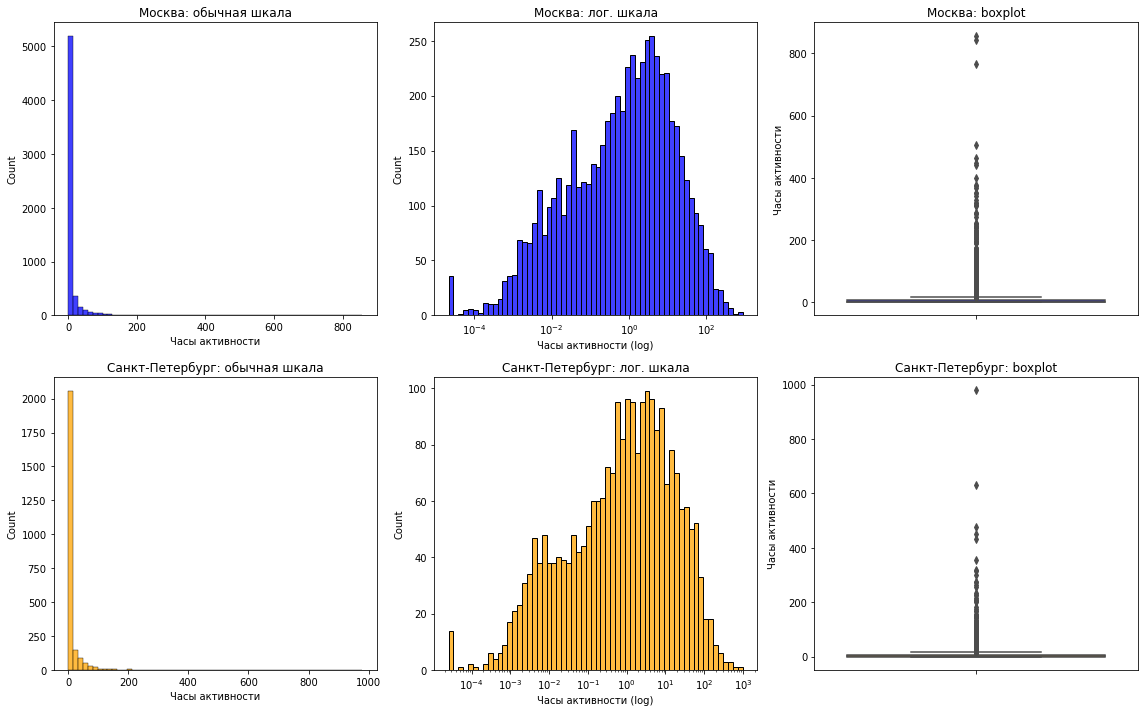

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

cities = [('Москва', msc, 'blue'), ('Санкт-Петербург', spb, 'orange')]

for row, (name, data, color) in enumerate(cities):
    # обычная шкала
    sns.histplot(data=data, x='hours', bins=60, ax=axes[row, 0],
                 stat='count', color=color)
    axes[row, 0].set_title(f'{name}: обычная шкала')
    axes[row, 0].set_xlabel('Часы активности')

    # логарифмическая шкала
    sns.histplot(data=data, x='hours', bins=60, ax=axes[row, 1],
                 stat='count', log_scale=True, color=color)
    axes[row, 1].set_title(f'{name}: лог. шкала')
    axes[row, 1].set_xlabel('Часы активности (log)')

    # boxplot
    sns.boxplot(data=data, y='hours', ax=axes[row, 2], color=color)
    axes[row, 2].set_title(f'{name}: boxplot')
    axes[row, 2].set_ylabel('Часы активности')

plt.tight_layout()
plt.show()

**Промежуточный вывод:**<br>
- Форма распределений в обоих городах визуально почти идентична.
- Наибольшее количество значений в обоих городах находится ближе к нулю.
- На boxplot видно много выбросов в обоих городах. Они влияют на среднее.
- Для стат. теста будем использовать односторонний t-теста Уэлча, т.к. наши выборки независимы, он не требует равенства дисперсий, он не требует равных выборок и устойчив к умеренным отклонениям от нормальности. У нас есть достаточно большое количество наблюдений и центральная предельная теорема (ЦПТ) гарантирует, что у выборочного среднего будет нормальное распределение если имеется больше 30 наблюдений.

## 2. Проверка гипотезы в Python

Гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [11]:
alpha = 0.05

t_stat, p_value = stats.ttest_ind(
    spb['hours'], msc['hours'],
    equal_var=False,      # параметр отвечает за тест Уэлча
    alternative='greater' # односторонний: проверяем, что mu(СПб) > mu(Мск)
)

print(f't-статистика: {t_stat:.4f}')
print(f'p-value: {p_value:.4f}')

if p_value < alpha:
    print('Отвергаем H0: активность в СПб статистически значимо выше')
else:
    print('Не отвергаем H0: недостаточно оснований считать активность в СПб выше')

t-статистика: 1.0902
p-value: 0.1378
Не отвергаем H0: недостаточно оснований считать активность в СПб выше


## 3. Аналитическая записка

**1. Тип теста и уровень значимости**

Для проверки гипотезы был использован односторонний t-тест Уэлча с уровнем значимости α = 0.05.

Тест Уэлча выбран потому что:
   - выборки независимы. Было обработано 244 дубля и каждый пользователь относится только к одному городу;
   - группы сильно различаются по размеру (МСК - 6099, СПб - 2441 пользователь);
   - тест не требует равенства дисперсий и корректно работает при неравных объемах групп.
   - имеющаяся асимметричность распределения (среднее заметно превышает медиану, много выбросов на boxplot) не мешает применению t-теста благодаря большому объёму выборок - по ЦПТ распределение выборочного среднего приближается к нормальному.

**2. Результат теста:** p-value = 0.1378

**3. Интерпретация результатов**

Так как полученное p-value (0.1378) больше уровня значимости α = 0.05, у нас недостаточно статистических оснований отклонить нулевую гипотезу.<br>
Это значит, что на основе имеющихся данных нельзя утверждать, что пользователи Санкт-Петербурга в среднем проводят статистически значимо больше времени за чтением и прослушиванием контента, чем пользователи Москвы. Наблюдаемая разница обычных средних в 1.04 ч. (СПб 12.15 ч. vs МСК 11.11 ч.) может объясняться случайной изменчивостью выборки, а не реальным различием в поведении пользователей на уровне генеральной совокупности.

**4. Возможные причины результата**
   - Город не является ключевым фактором активности. Время чтения и прослушивания, скорее всего, сильнее зависит от индивидуальных привычек пользователя (жанровые предпочтения, наличие подписки, свободное время, тип устройства), чем от географии проживания. То есть сама гипотеза о влиянии города могла быть изначально ошибочной.
   - Возможно, дело в самой выбранной метрике и разница между СПб и МСК есть, но не в часах активности, а в чем-то другом. Например, в частоте сессий, типе контента (детский/взрослый), жанрах или платформе.
   - Большой разброс данных. Стандартное отклонение в обеих группах (37–41 час) в десятки раз превышает саму разницу средних (~1,04 ч.), а единичные «супер-активные» пользователи (выбросы до 857–979 часов) вносят большой вклад в дисперсию. Это размывает возможный реальный эффект между городами и требует очень большой разницы, чтобы тест счёл её значимой.

# Часть 2. Анализ результатов A/B-тестирования

Теперь вам нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

## 1. Опишите цели исследования.



**Цель исследования** - оценить, привёл ли новый упрощённый дизайн сайта к увеличению конверсии зарегистрированных пользователей в покупателей на 3 п.п. в течение 7 дней после регистрации.

**Задачи:**

1. Проверить корректность теста — равномерность распределения по группам, отсутствие пересечений пользователей, соответствие событий 2020 году и условию 7 дней после регистрации.
2. Рассчитать конверсию в покупку для контрольной (А) и экспериментальной (В) групп в течение 7 дней с момента регистрации.
3. Сравнить фактический прирост конверсии (в процентных пунктах) с требуемым.
4. Оценить статистическую значимость различий конверсий.
5. Сформулировать вывод - целесообразно ли внедрять новый интерфейс для всех пользователей.

**Описание данных:**

В таблице `ab_test_participants.csv` содержатся данные участников тестов:<br>
- `user_id` — идентификатор пользователя;
- `group` — группа пользователя;
- `ab_test` — название теста;
- `device` — устройство, с которого происходила регистрация.

В архиве `ab_test_events.zip` содержится один csv-файлом, в котором собраны события 2020 года. Структура файла:<br>
- `user_id` — идентификатор пользователя;
- `event_dt` — дата и время события;
- `event_name` — тип события;
- `details` — дополнительные данные о событии.

Дополнительная информация по столбцу `details`. Числовые значения:
- `registration (регистрация)` — стоимость привлечения клиента;
- `purchase (покупка)` — стоимость покупки.

Расшифровка кодов зон:

|    |     Код     |                     Зона |
|:--:|:-----------:|-------------------------:|
| 0  | ZONE_CODE00 | None                     |
| 1  | ZONE_CODE01 | EU                       |
| 2  | ZONE_CODE02 | CIS                      |
| 3  | ZONE_CODE03 | EU, CIS                  |
| 4  | ZONE_CODE04 | APAC                     |
| 5  | ZONE_CODE05 | EU, APAC                 |
| 6  | ZONE_CODE06 | CIS, APAC                |
| 7  | ZONE_CODE07 | EU, CIS, APAC            |
| 8  | ZONE_CODE08 | N.America                |
| 9  | ZONE_CODE09 | EU, N.America            |
| 10 | ZONE_CODE10 | CIS, N.America           |
| 11 | ZONE_CODE11 | EU, CIS, N.America       |
| 12 | ZONE_CODE12 | APAC, N.America          |
| 13 | ZONE_CODE13 | EU, APAC, N.America      |
| 14 | ZONE_CODE14 | CIS, APAC, N.America     |
| 15 | ZONE_CODE15 | EU, CIS, APAC, N.America |


## 2. Загрузите данные, оцените их целостность.


In [12]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [13]:
participants.info()
display(participants.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [14]:
events.info()
display(events.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [15]:
# Проверим заполненность значений по каждому событию
display(events.groupby('event_name')['details'].agg(total='size', filled='count'))

,total,filled
event_name,,
End of Black Friday Ads Campaign,1,1
Start of CIS New Year Gift Lottery,1,1
Start of Christmas&New Year Promo,1,1
login,248285,0
product_cart,94373,0
product_page,195606,0
purchase,104836,104836
registration,144183,144183


**Промежуточный вывод:**<br>
- Датафрейм `participants` содержит 14525 строк и 4 столбца, все они заполнены.
- Датафрейм `events` содержит 787286 строк и 4 столбца. Есть пропуски в стольце `details`. Это не ошибка в данных, а особенность их структуры. Столбец хранит разную информацию в зависимости от event_name, и заполнен только там, где это применимо. Пропуски содержатся в следующих событиях:
| event_name   | Всего строк | Заполнено |
|--------------|-------------|-----------|
|        login |      248285 |         0 |
| product_cart |       94373 |         0 |
| product_page |      195606 |         0 |

In [16]:
# Проверим полные дубликаты в participants и дубликаты user_id внутри одного теста (и возможно группы)
display(f"Всего дубликатов в participants: {participants.duplicated().sum()}")
dup_in_test = participants.duplicated(subset=['user_id', 'ab_test']).sum()
print(f'Дублей user_id в participants внутри одного теста: {dup_in_test}')

# Проверим полные дубликаты в events
display(f"Всего дубликатов в events: {events.duplicated().sum()}")

'Всего дубликатов в participants: 0'

Дублей user_id в participants внутри одного теста: 0


'Всего дубликатов в events: 36318'

In [17]:
# Удалим полные дубликаты и ещё раз проверим
events = events.drop_duplicates()

display(f"Всего дубликатов в events: {events.duplicated().sum()}")

'Всего дубликатов в events: 0'

**Промежуточный вывод:**<br>
- В participants нет дублей.
- в events было удалено 36318 дублей.

## 3. По таблице `ab_test_participants` оцените корректность проведения теста:

   3\.1 Выделите пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [18]:
# Проверим какие тесты вообще есть в таблице, как они называются и сколько в них участников
test_stats = participants.groupby(['ab_test', 'group'])['user_id'].nunique().reset_index()
test_stats.columns = ['ab_test', 'group', 'user_count']
test_stats['share'] = round(test_stats.groupby('ab_test')['user_count'].transform(lambda x: x / x.sum()),2)
display(test_stats)

,ab_test,group,user_count,share
0,interface_eu_test,A,5383,0.50
1,interface_eu_test,B,5467,0.50
2,recommender_system_test,A,2747,0.75
3,recommender_system_test,B,928,0.25


In [19]:
# Проверим пересечения с другими тестами
# Название нужного теста
test_name = 'interface_eu_test'

# Выделим участников теста
test_participants = participants[participants['ab_test'] == test_name]

users_in_test = set(test_participants['user_id'])
other_tests = participants[participants['ab_test'] != test_name]
overlap = other_tests[other_tests['user_id'].isin(users_in_test)]

print(f'Пересекающиеся пользователи: {overlap["user_id"].nunique()}')

Пересекающиеся пользователи: 887


**Промежуточный вывод:**<br>
Выявлено 887 пользователей которые одновременно участвуют в двух тестах (interface_eu_test и recommender_system_test). Так как тесты могут влиять друг на друга, пересекающихся пользователей нужно исключить для чистой оценки.

In [20]:
# Пересекающиеся пользователи
overlapping_users = set(overlap['user_id'])

# Убираем их из interface_eu_test
clean_test_participants = test_participants[~test_participants['user_id'].isin(overlapping_users)]

print(f'Было участников теста: {len(test_participants)}')
print(f'Пересекающихся пользователей: {len(overlapping_users)}')
print(f'Осталось после очистки: {len(clean_test_participants)}')

Было участников теста: 10850
Пересекающихся пользователей: 887
Осталось после очистки: 9963


In [21]:
# Проверим, что очистка не повлияла на равномерность групп
print('До очистки:')
print(test_participants['group'].value_counts())
print()
print('После очистки:')
print(clean_test_participants['group'].value_counts())

До очистки:
B    5467
A    5383
Name: group, dtype: int64

После очистки:
B    5011
A    4952
Name: group, dtype: int64


**Промежуточный вывод:**<br>
- Получившиеся выборки пользователей соответствуют требованиям технического задания.
- Изначально в тест interface_eu_test попало 10850 пользователей, 5383 в группе А и 5467 в группе Б, но было выявлено 887 пользователей которые одновременно участвуют в двух тестах. Для чистоты оценки эти пользователи были исключены. После очистки размеры выборок остались практически равны и составили: группа А = 4952, группа B = 5011.

3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

In [22]:
test_user_ids = set(clean_test_participants['user_id'])

test_events = events[events['user_id'].isin(test_user_ids)]

print(f'Всего событий: {len(events)}')
print(f'Событий участников теста interface_eu_test: {len(test_events)}')
print(f'Уникальных пользователей в отфильтрованных событиях: {test_events["user_id"].nunique()}')

Всего событий: 750968
Событий участников теста interface_eu_test: 68074
Уникальных пользователей в отфильтрованных событиях: 9963


In [23]:
# Проверка, что у всех участников теста вообще есть события
users_without_events = test_user_ids - set(test_events['user_id'])
print(f'Участников теста без единого события: {len(users_without_events)}')

Участников теста без единого события: 0


In [24]:
# Проверка, что у всех участников теста есть регистрация
users_with_registration = set(
    test_events[test_events['event_name'] == 'registration']['user_id']
)
users_without_registration = test_user_ids - users_with_registration
print(f'Участников теста без registration: {len(users_without_registration)}')

Участников теста без registration: 0


In [25]:
# Объединим пользователей и события
test_events = test_events.merge(
    clean_test_participants[['user_id', 'group']],
    on='user_id',
    how='left'
)

test_events.head()

,user_id,event_dt,event_name,details,group
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,A
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,A
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,B
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,A
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,B


- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [26]:
# Определяем дату регистрации каждого пользователя
registration_dt = (
    test_events[test_events['event_name'] == 'registration']
    .groupby('user_id')['event_dt']
    .min()  # на всякий случай берём самую раннюю
    .rename('registration_dt')
)

In [27]:
# Присоединяем дату регистрации к событиям
test_events = test_events.merge(registration_dt, on='user_id', how='left')
test_events.head()

,user_id,event_dt,event_name,details,group,registration_dt
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,A,2020-12-06 14:10:01
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,A,2020-12-06 14:37:25
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,B,2020-12-06 17:20:22
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,A,2020-12-06 19:36:54
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,B,2020-12-06 19:42:20


In [28]:
# Cчитаем лайфтайм для каждого события
test_events['lifetime'] = test_events['event_dt'] - test_events['registration_dt']

In [29]:
# Оставляем только события произошедшие за первые 7 дней
horizon = pd.Timedelta(days=7)

events_within_horizon = test_events[
    (test_events['lifetime'] >= pd.Timedelta(0)) &
    (test_events['lifetime'] <= horizon)
]

print(f'Событий до фильтра: {len(test_events)}')
print(f'Событий в пределах 7 дней после регистрации: {len(events_within_horizon)}')
print(f'Уникальных пользователей в: {events_within_horizon["user_id"].nunique()}')

Событий до фильтра: 68074
Событий в пределах 7 дней после регистрации: 58692
Уникальных пользователей в: 9963


Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [30]:
# Параметры:
alpha = 0.05  # Уровень значимости
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень конверсии
mde = 0.03  # Увеличение конверсии на 3 п.п.

effect_size = proportion_effectsize(p + mde, p)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1, # Равномерное распределение выборок
    alternative='larger'
)

print(f"Необходимый размер выборки для каждой группы: {math.ceil(sample_size)}")

Необходимый размер выборки для каждой группы: 2964


**Промежуточный вывод:**<br>
- Фактические размеры групп (A = 4952, B = 5011) превышают требуемый минимум в ~2964. Это значит, что выборки достаточны для обнаружения эффекта в 3 п.п. с заданными мощностью (80%) и достоверностью (95%) при одностороннем тесте.

- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [31]:
# Считаем общее количество посетителей
total_visitors = (
    events_within_horizon
    .drop_duplicates(subset='user_id')  # каждый пользователь учитывается один раз
    .groupby('group')['user_id']
    .nunique()
)

print('Общее количетсво посетителей по группам:')
print(total_visitors)

Общее количетсво посетителей по группам:
group
A    4952
B    5011
Name: user_id, dtype: int64


In [32]:
# Считаем общее количество покупателей
buyers = (
    events_within_horizon[events_within_horizon['event_name'] == 'purchase']
    .groupby('group')['user_id']
    .nunique()
)

print('Покупателей по группам:')
print(buyers)

Покупателей по группам:
group
A    1377
B    1480
Name: user_id, dtype: int64


In [33]:
# Соберем данные в таблицу
summary = pd.DataFrame({
    'total_visitors': total_visitors,
    'buyers': buyers
})

summary['conversion_rate_%'] = (summary['buyers'] / summary['total_visitors'] * 100).round(2)

display(summary)

# Абсолютный и относительный прирост конверсии группы B относительно группы A
cr_a = summary.loc['A', 'conversion_rate_%']
cr_b = summary.loc['B', 'conversion_rate_%']

absolute_diff = round(cr_b - cr_a, 2)
relative_diff = round((cr_b - cr_a) / cr_a * 100, 2)

print(f'Абсолютный прирост: {absolute_diff} п.п.')
print(f'Относительный прирост: {relative_diff}%')

,total_visitors,buyers,conversion_rate_%
group,,,
A,4952,1377,27.81
B,5011,1480,29.54


Абсолютный прирост: 1.73 п.п.
Относительный прирост: 6.22%


- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

**Предварительный вывод:**<br>
Прирост конверсии в группе B есть, но он меньше, чем предполагалось в гипотезе.

Абсолютный прирост прирост составил 29.54% − 27.81% = 1.73 п.п., что меньше 3 п.п.

Относительный прирост поставил: (29.54 − 27.81) / 27.81 × 100% ≈ 6.2%. Конверсия в тестовой группе выросла примерно на 6% относительно базового уровня.


Новый интерфейс (группа B) показывает более высокую конверсию в покупку по сравнению со старым (группа A) - 29.54% против 27.81%. Направление эффекта соответствует гипотезе: упрощение интерфейса действительно может быть связано с ростом конверсии. Но необходимо проведение статистического текста, чтобы понять является ли разнциа статистически значимой или это шум.

## 4. Проведите оценку результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

Для оценки будем использовать **Z-тест пропорций**. Он позволяет определить, существует ли значимая разница между долями в двух независимых выборках с бинарным исходом (купил/не купил в нашем случае). Также размеры групп (~5000 чел.) позволяют опираться на нормальное распределение.

**Формулировки гипотез:**<br>
H₀: конверсия в группе B ≤ конверсии в группе A (новый интерфейс не лучше)<br>
H₁: конверсия в группе B > конверсии в группе A (новый интерфейс лучше)<br>

In [34]:

# Считаем количество покупок (успехов) и общее количество наблюдений по группам
successes = [summary.loc['B', 'buyers'], summary.loc['A', 'buyers']]
numbers = [summary.loc['B', 'total_visitors'], summary.loc['A', 'total_visitors']]

z_stat, p_value = proportions_ztest(
    successes,
    numbers,
    alternative='larger'  # конверсия B > конверсии A
)

alpha = 0.05

if p_value < alpha:
    print(f'p-value ({p_value:.4f}) < alpha ({alpha}) — отклоняем H0.')
    print('Конверсия в группе B статистически значимо выше, чем в группе A.')
else:
    print(f'p-value ({p_value:.4f}) >= alpha ({alpha}) — не отклоняем H0.')
    print('Недостаточно оснований утверждать, что конверсия в B выше, чем в A.')

p-value (0.0283) < alpha (0.05) — отклоняем H0.
Конверсия в группе B статистически значимо выше, чем в группе A.


## 5. Итоговый вывод:
**1. Корректность проведения теста**

Тест interface_eu_test организован технически корректно и соответствует ТЗ. Полных дублей внутри теста не найдено, 887 пользователей, пересекавшихся с конкурирующим тестом recommender_system_test были исключены. После очистки группы остались почти равны по размеру (A = 4952, B = 5011).

**2. Достаточность выборки**

Расчёт мощности для одностороннего теста при базовой конверсии 30%, MDE = 3 п.п., уровнем значимости = 0.05, мощности 80% показал, что необходимо минимум 2964 пользователя на группу. Фактические размеры групп больше (A = 4952, B = 5011).

**3. Проверка стат. значимости**

Был проведен односторонний Z-тест пропорций и получено p-value = 0.0283, что меньше уровня значимости α = 0.05. Нулевая гипотеза о том, что конверсия B ≤ конверсии A отклоняется. Конверсия в группе B статистически значимо выше, чем в группе A. То есть наблюдаемая разница является не случайным шумом, а реальный эффектом от нового упрощенного интерфейса.

**4. Достигнут ли эффект, заявленный в ТЗ**

ТЗ требовало, что конверсия зарегистрированных пользователей в покупателей увеличится как минимум на 3 п.п. По факту:
- конверсия A = 27.81%,
- конверсия B = 29.54%;
- абсолютный прирост = 1.73 п.п., что меньше необходимого порога в 3 п.п.;
- относительный прирост = 6.22%.

Таким образом, новый интерфейс действительно повышает конверсию, и это статистически доказано. Но ожидаемый по ТЗ эффект в 3 п.п. не был достигнут, фактический прирост составил только 1.73 п.п.

**Рекомендации:**
1. не отклонять гипотезу об улучшении интерфейса полностью (эффект есть и он положительный), но и не считать цель ТЗ выполненной в заявленном объёме. Возможно стоит обсудить с заказчиком, является ли прирост в ~1.7 п.п. (или ~6% относительно) экономически достаточным.
2. провести оценку экономического эффекта от увеличения конверсии на 1.7 п.п. для приянтия более взвешанного решения о внедрении нового интерфейса для всех пользователей.